# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- **Use Pandas to load, inspect, and clean the dataset appropriately.**
- **Transform relevant columns to create measures that address the problem at hand.**
- conduct EDA: visualization and statistical measures to systematically understand the structure of the data
- recommend a set of airplanes and makes conforming to the client's request and identify at least *two* factors contributing to airplane safety. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.

### Make relevant library imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


## Data Loading and Inspection

In [2]:
# We need to load the aviation file for analysis
df = pd.read_csv("AviationData.csv", encoding='ISO-8859-1')
df

C:\Users\Admin\AppData\Local\Temp\ipykernel_10428\3249371875.py:2: DtypeWarning: Columns (0: Latitude, 1: Longitude, 2: Broad.phase.of.flight) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("AviationData.csv", encoding='ISO-8859-1')


,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause,NaN
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause,19-09-1996
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,36.922223,-81.878056,NaN,NaN,...,Personal,NaN,3.0,NaN,NaN,NaN,IMC,Cruise,Probable Cause,26-02-2007
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,IMC,Cruise,Probable Cause,12-09-2000
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,1.0,2.0,NaN,0.0,VMC,Approach,Probable Cause,16-04-1980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88884,20221227106491,Accident,ERA23LA093,2022-12-26,"Annapolis, MD",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,0.0,1.0,0.0,0.0,NaN,NaN,NaN,29-12-2022
88885,20221227106494,Accident,ERA23LA095,2022-12-26,"Hampton, NH",United States,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
88886,20221227106497,Accident,WPR23LA075,2022-12-26,"Payson, AZ",United States,341525N,1112021W,PAN,PAYSON,...,Personal,NaN,0.0,0.0,0.0,1.0,VMC,NaN,NaN,27-12-2022
88887,20221227106498,Accident,WPR23LA076,2022-12-26,"Morgan, UT",United States,NaN,NaN,NaN,NaN,...,Personal,MC CESSNA 210N LLC,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN


### Load in data from the relevant directory and inspect the dataframe.
- inspect NaNs, datatypes, and summary statistics

In [3]:
# we want to see the first 5 rows of our dataset
df.head()

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause,NaN
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause,19-09-1996
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,36.922223,-81.878056,NaN,NaN,...,Personal,NaN,3.0,NaN,NaN,NaN,IMC,Cruise,Probable Cause,26-02-2007
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,IMC,Cruise,Probable Cause,12-09-2000
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,1.0,2.0,NaN,0.0,VMC,Approach,Probable Cause,16-04-1980


In [4]:
# Inspecting the last rows of our dataset
df.tail()

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
88884,20221227106491,Accident,ERA23LA093,2022-12-26,"Annapolis, MD",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,0.0,1.0,0.0,0.0,NaN,NaN,NaN,29-12-2022
88885,20221227106494,Accident,ERA23LA095,2022-12-26,"Hampton, NH",United States,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
88886,20221227106497,Accident,WPR23LA075,2022-12-26,"Payson, AZ",United States,341525N,1112021W,PAN,PAYSON,...,Personal,NaN,0.0,0.0,0.0,1.0,VMC,NaN,NaN,27-12-2022
88887,20221227106498,Accident,WPR23LA076,2022-12-26,"Morgan, UT",United States,NaN,NaN,NaN,NaN,...,Personal,MC CESSNA 210N LLC,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
88888,20221230106513,Accident,ERA23LA097,2022-12-29,"Athens, GA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,0.0,1.0,0.0,1.0,NaN,NaN,NaN,30-12-2022


In [5]:
# Getting a list of all the columns in the dataset
df.columns.tolist()

['Event.Id',
 'Investigation.Type',
 'Accident.Number',
 'Event.Date',
 'Location',
 'Country',
 'Latitude',
 'Longitude',
 'Airport.Code',
 'Airport.Name',
 'Injury.Severity',
 'Aircraft.damage',
 'Aircraft.Category',
 'Registration.Number',
 'Make',
 'Model',
 'Amateur.Built',
 'Number.of.Engines',
 'Engine.Type',
 'FAR.Description',
 'Schedule',
 'Purpose.of.flight',
 'Air.carrier',
 'Total.Fatal.Injuries',
 'Total.Serious.Injuries',
 'Total.Minor.Injuries',
 'Total.Uninjured',
 'Weather.Condition',
 'Broad.phase.of.flight',
 'Report.Status',
 'Publication.Date']

In [6]:
# Fixing the column names
# We want to replace the . to _ and have the names in lowercase
df.columns = (df.columns.str.replace('.', '_', regex=False).str.lower()
)

In [7]:
df.columns.tolist()

['event_id',
 'investigation_type',
 'accident_number',
 'event_date',
 'location',
 'country',
 'latitude',
 'longitude',
 'airport_code',
 'airport_name',
 'injury_severity',
 'aircraft_damage',
 'aircraft_category',
 'registration_number',
 'make',
 'model',
 'amateur_built',
 'number_of_engines',
 'engine_type',
 'far_description',
 'schedule',
 'purpose_of_flight',
 'air_carrier',
 'total_fatal_injuries',
 'total_serious_injuries',
 'total_minor_injuries',
 'total_uninjured',
 'weather_condition',
 'broad_phase_of_flight',
 'report_status',
 'publication_date']

In [8]:
# To inspect the datatypes in the dataset
df.info()
# From the output, we can see that we have non_Null counts in all rows except the event.id, investigation type, accident number, and event date

<class 'pandas.DataFrame'>
RangeIndex: 88889 entries, 0 to 88888
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   event_id                88889 non-null  str    
 1   investigation_type      88889 non-null  str    
 2   accident_number         88889 non-null  str    
 3   event_date              88889 non-null  str    
 4   location                88837 non-null  str    
 5   country                 88663 non-null  str    
 6   latitude                34382 non-null  object 
 7   longitude               34373 non-null  object 
 8   airport_code            50132 non-null  str    
 9   airport_name            52704 non-null  str    
 10  injury_severity         87889 non-null  str    
 11  aircraft_damage         85695 non-null  str    
 12  aircraft_category       32287 non-null  str    
 13  registration_number     87507 non-null  str    
 14  make                    88826 non-null  str    
 

In [9]:
# Making a copy of the original dataset since we dont want to alter it
df1 = df.copy()
df1

,event_id,investigation_type,accident_number,event_date,location,country,latitude,longitude,airport_code,airport_name,...,purpose_of_flight,air_carrier,total_fatal_injuries,total_serious_injuries,total_minor_injuries,total_uninjured,weather_condition,broad_phase_of_flight,report_status,publication_date
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause,NaN
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause,19-09-1996
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,36.922223,-81.878056,NaN,NaN,...,Personal,NaN,3.0,NaN,NaN,NaN,IMC,Cruise,Probable Cause,26-02-2007
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,IMC,Cruise,Probable Cause,12-09-2000
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,1.0,2.0,NaN,0.0,VMC,Approach,Probable Cause,16-04-1980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88884,20221227106491,Accident,ERA23LA093,2022-12-26,"Annapolis, MD",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,0.0,1.0,0.0,0.0,NaN,NaN,NaN,29-12-2022
88885,20221227106494,Accident,ERA23LA095,2022-12-26,"Hampton, NH",United States,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
88886,20221227106497,Accident,WPR23LA075,2022-12-26,"Payson, AZ",United States,341525N,1112021W,PAN,PAYSON,...,Personal,NaN,0.0,0.0,0.0,1.0,VMC,NaN,NaN,27-12-2022
88887,20221227106498,Accident,WPR23LA076,2022-12-26,"Morgan, UT",United States,NaN,NaN,NaN,NaN,...,Personal,MC CESSNA 210N LLC,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN


In [10]:
# Checking for duplicates
df1.duplicated().sum()
#we have none

0

In [11]:
# We want to validate our data by inspecting the data types we have
df1.dtypes


event_id                      str
investigation_type            str
accident_number               str
event_date                    str
location                      str
country                       str
latitude                   object
longitude                  object
airport_code                  str
airport_name                  str
injury_severity               str
aircraft_damage               str
aircraft_category             str
registration_number           str
make                          str
model                         str
amateur_built                 str
number_of_engines         float64
engine_type                   str
far_description               str
schedule                      str
purpose_of_flight             str
air_carrier                   str
total_fatal_injuries      float64
total_serious_injuries    float64
total_minor_injuries      float64
total_uninjured           float64
weather_condition             str
broad_phase_of_flight         str
report_status 

In [12]:
df1.select_dtypes(include='object').columns

C:\Users\Admin\AppData\Local\Temp\ipykernel_10428\3423119933.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df1.select_dtypes(include='object').columns


Index(['event_id', 'investigation_type', 'accident_number', 'event_date',
       'location', 'country', 'latitude', 'longitude', 'airport_code',
       'airport_name', 'injury_severity', 'aircraft_damage',
       'aircraft_category', 'registration_number', 'make', 'model',
       'amateur_built', 'engine_type', 'far_description', 'schedule',
       'purpose_of_flight', 'air_carrier', 'weather_condition',
       'broad_phase_of_flight', 'report_status', 'publication_date'],
      dtype='str')

## Data Cleaning

### Filtering aircrafts and events

We want to filter the dataset to include aircraft that the client is interested in an analysis of:
- inspect relevant columns
- figure out any reasonable imputations
- filter the dataset

In [13]:
# Inspecting relevant columns
relevant_cols = ['event_date',
    'aircraft_category',
    'amateur_built',
    'make',
    'model',
    'aircraft_damage',
    'total_fatal_injuries',
    'total_serious_injuries',
    'total_minor_injuries',
    'total_uninjured',
    'weather_condition',
    'broad_phase_of_flight']
    


In [14]:
df1[relevant_cols].head()

,event_date,aircraft_category,amateur_built,make,model,aircraft_damage,total_fatal_injuries,total_serious_injuries,total_minor_injuries,total_uninjured,weather_condition,broad_phase_of_flight
0,1948-10-24,NaN,No,Stinson,108-3,Destroyed,2.0,0.0,0.0,0.0,UNK,Cruise
1,1962-07-19,NaN,No,Piper,PA24-180,Destroyed,4.0,0.0,0.0,0.0,UNK,Unknown
2,1974-08-30,NaN,No,Cessna,172M,Destroyed,3.0,NaN,NaN,NaN,IMC,Cruise
3,1977-06-19,NaN,No,Rockwell,112,Destroyed,2.0,0.0,0.0,0.0,IMC,Cruise
4,1979-08-02,NaN,No,Cessna,501,Destroyed,1.0,2.0,NaN,0.0,VMC,Approach


In [15]:
df1[relevant_cols].tail()

,event_date,aircraft_category,amateur_built,make,model,aircraft_damage,total_fatal_injuries,total_serious_injuries,total_minor_injuries,total_uninjured,weather_condition,broad_phase_of_flight
88884,2022-12-26,NaN,No,PIPER,PA-28-151,NaN,0.0,1.0,0.0,0.0,NaN,NaN
88885,2022-12-26,NaN,No,BELLANCA,7ECA,NaN,0.0,0.0,0.0,0.0,NaN,NaN
88886,2022-12-26,Airplane,No,AMERICAN CHAMPION AIRCRAFT,8GCBC,Substantial,0.0,0.0,0.0,1.0,VMC,NaN
88887,2022-12-26,NaN,No,CESSNA,210N,NaN,0.0,0.0,0.0,0.0,NaN,NaN
88888,2022-12-29,NaN,No,PIPER,PA-24-260,NaN,0.0,1.0,0.0,1.0,NaN,NaN



 #### step 1
 ##### Cleaning all the common issues from the relevant columns

In [16]:
# cleaning the text columns

for col in ['aircraft_category', 'amateur_built', 'make', 'model']:
    df1[col] = df1[col].str.strip().str.lower()
    print(df1.shape)
df1.head()

(88889, 31)
(88889, 31)
(88889, 31)
(88889, 31)


,event_id,investigation_type,accident_number,event_date,location,country,latitude,longitude,airport_code,airport_name,...,purpose_of_flight,air_carrier,total_fatal_injuries,total_serious_injuries,total_minor_injuries,total_uninjured,weather_condition,broad_phase_of_flight,report_status,publication_date
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause,NaN
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause,19-09-1996
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,36.922223,-81.878056,NaN,NaN,...,Personal,NaN,3.0,NaN,NaN,NaN,IMC,Cruise,Probable Cause,26-02-2007
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,IMC,Cruise,Probable Cause,12-09-2000
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,1.0,2.0,NaN,0.0,VMC,Approach,Probable Cause,16-04-1980


In [17]:
# Date conversion
df1['event_date'] = pd.to_datetime(df1['event_date'], errors='coerce')
df1['event_date'].dtype

dtype('<M8[us]')

In [18]:
# Checking for failed datetime conversions
df1['event_date'].isna().sum()

0

In [19]:
df1 = df1[
# only in airplanes
    (df1['aircraft_category'] == 'airplane') &
# Inspecting the professional built and eliminating amateurs
    (df1['amateur_built'] == 'no') &
# creating a list of only 40 years and above, starting from 1983
    (df1['event_date'].dt.year >= 1983)
]
df1[relevant_cols].head()

,event_date,aircraft_category,amateur_built,make,model,aircraft_damage,total_fatal_injuries,total_serious_injuries,total_minor_injuries,total_uninjured,weather_condition,broad_phase_of_flight
4149,1983-03-18,airplane,no,lockheed,l-1011,Minor,NaN,NaN,NaN,588.0,VMC,Standing
4150,1983-03-18,airplane,no,boeing,747,Minor,NaN,NaN,NaN,588.0,VMC,Taxi
4171,1983-03-20,airplane,no,piper,pa-28-140,Destroyed,1.0,1.0,NaN,NaN,IMC,Cruise
4285,1983-04-02,airplane,no,de havilland,dhc-6,NaN,1.0,NaN,NaN,4.0,VMC,Standing
5957,1983-08-21,airplane,no,douglas,dc-10-10,Minor,NaN,NaN,NaN,289.0,VMC,Cruise


### Cleaning and constructing Key Measurables

Injuries and robustness to destruction are a key interest point for the client. Clean and impute relevant columns and then create derived fields that best quantifies what the client wishes to track. **Use commenting or markdown to explain any cleaning assumptions as well as any derived columns you create.**

**Construct metric for fatal/serious injuries**

*Hint:* Estimate the total number of passengers on each flight. The likelihood of serious / fatal injury can be estimated as a fraction from this.

#### We need to convert the injury columns to numeric for us to calculate the missing values to achieve a consistent calculation.

In [20]:
df1 = df1.copy()

injury_cols = [
    'total_fatal_injuries',
    'total_serious_injuries',
    'total_minor_injuries',
    'total_uninjured'
]

for col in injury_cols:
    df1[col] = pd.to_numeric(df1[col], errors='coerce')
    df1[injury_cols] = df1[injury_cols].fillna(0)
df1[injury_cols].describe()


,total_fatal_injuries,total_serious_injuries,total_minor_injuries,total_uninjured
count,21447.000000,21447.000000,21447.000000,21447.000000
mean,0.645871,0.280692,0.203245,7.462489
std,6.326507,2.218737,1.647516,35.064707
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,1.000000
75%,0.000000,0.000000,0.000000,2.000000
max,295.000000,161.000000,200.000000,588.000000


#### We need to get an eastimate of the passengers injured and the degree of the injury if fatal or serious.

In [21]:
df1.columns

Index(['event_id', 'investigation_type', 'accident_number', 'event_date',
       'location', 'country', 'latitude', 'longitude', 'airport_code',
       'airport_name', 'injury_severity', 'aircraft_damage',
       'aircraft_category', 'registration_number', 'make', 'model',
       'amateur_built', 'number_of_engines', 'engine_type', 'far_description',
       'schedule', 'purpose_of_flight', 'air_carrier', 'total_fatal_injuries',
       'total_serious_injuries', 'total_minor_injuries', 'total_uninjured',
       'weather_condition', 'broad_phase_of_flight', 'report_status',
       'publication_date'],
      dtype='str')

In [22]:
df1['eastimated_passengers'] = df1[injury_cols].sum(axis=1)

df1['serious_or_fatal'] = (
    (df1['total_fatal_injuries'] > 0) |
    (df1['total_serious_injuries'] > 0)
)
df1['total_destruction'] = df1['aircraft_damage'] == 'destroyed'
df1[['eastimated_passengers', 'serious_or_fatal', 'total_destruction']].head()


,eastimated_passengers,serious_or_fatal,total_destruction
4149,588.0,False,False
4150,588.0,False,False
4171,2.0,True,False
4285,5.0,True,False
5957,289.0,False,False


**Aircraft.Damage**
- identify and execute any cleaning tasks
- construct a derived column tracking whether an aircraft was destroyed or not.

#### Aircraft Damage data cleaning

In [23]:
df1['aircraft_damage'] = df1['aircraft_damage'].astype(str).str.strip().str.lower()
df1['total_destruction'] = df1['aircraft_damage'].eq('destroyed')
df1['aircraft_damage'].value_counts().head(10)

aircraft_damage
substantial    16990
destroyed       2316
minor            817
unknown           97
Name: count, dtype: int64

In [24]:
df1['total_destruction'].mean()

0.10798713106728214

### Investigate the *Make* column
- Identify cleaning tasks here
- List cleaning tasks clearly in markdown
- Execute the cleaning tasks
- For your analysis, keep Makes with a reasonable number (you can put the threshold at 50 though lower could work as well)

In [25]:
df1['make'].value_counts().head(20)

make
cessna                7146
piper                 3989
beech                 1431
boeing                1264
mooney                 363
airbus                 243
cirrus design corp     220
bellanca               219
air tractor inc        219
maule                  215
air tractor            206
aeronca                200
champion               158
embraer                153
grumman                147
luscombe               141
cirrus                 137
stinson                129
mcdonnell douglas      108
north american         106
Name: count, dtype: int64

In [26]:
df1['make_clean'] = df1['make'].astype(str).str.strip().str.lower()

In [27]:
# Fixing the naming issues
df1['make_clean'] = df1['make_clean'].str.replace(
   r'\b(inc|corp|co|ltd|company|industrie|aircraft|ind|avn\.?)\b',
    '',
   regex=True
).str.replace(r'\s+', ' ', regex=True).str.strip()

In [28]:
df1[['make', 'make_clean']].drop_duplicates().head(20)

,make,make_clean
4149,lockheed,lockheed
4150,boeing,boeing
4171,piper,piper
4285,de havilland,de havilland
5957,douglas,douglas
6669,short brothers,short brothers
6806,beech,beech
7084,cessna,cessna
10140,swearingen,swearingen
12384,lake,lake


In [29]:
df1.columns

Index(['event_id', 'investigation_type', 'accident_number', 'event_date',
       'location', 'country', 'latitude', 'longitude', 'airport_code',
       'airport_name', 'injury_severity', 'aircraft_damage',
       'aircraft_category', 'registration_number', 'make', 'model',
       'amateur_built', 'number_of_engines', 'engine_type', 'far_description',
       'schedule', 'purpose_of_flight', 'air_carrier', 'total_fatal_injuries',
       'total_serious_injuries', 'total_minor_injuries', 'total_uninjured',
       'weather_condition', 'broad_phase_of_flight', 'report_status',
       'publication_date', 'eastimated_passengers', 'serious_or_fatal',
       'total_destruction', 'make_clean'],
      dtype='str')

In [30]:
df1['make'].value_counts().head(20)

make
cessna                7146
piper                 3989
beech                 1431
boeing                1264
mooney                 363
airbus                 243
cirrus design corp     220
bellanca               219
air tractor inc        219
maule                  215
air tractor            206
aeronca                200
champion               158
embraer                153
grumman                147
luscombe               141
cirrus                 137
stinson                129
mcdonnell douglas      108
north american         106
Name: count, dtype: int64

In [31]:
make_counts = df1['make'].value_counts()

valid_makes = make_counts[make_counts >= 50].index

df1 = df1[df1['make'].isin(valid_makes)]

df1['make'].value_counts().head()

make
cessna    7146
piper     3989
beech     1431
boeing    1264
mooney     363
Name: count, dtype: int64

### Inspect Model column
- Get rid of any NaNs.
- Inspect the column and counts for each model/make. Are model labels unique to each make?
- If not, create a derived column that is a unique identifier for a given plane type.

### Handling missing model values

In [32]:
df1 = df1.copy()

df1['model'] = df1['model'].fillna('unknown')

In [33]:
df1['make_model_pair'] = df1['make'] + " | " + df1['model']

df1['make_model_pair'].value_counts().head(20)

make_model_pair
cessna | 172                 769
boeing | 737                 403
cessna | 152                 316
cessna | 182                 304
cessna | 172s                276
piper | pa28                 273
cessna | 172n                249
cessna | 180                 213
cessna | 172m                180
cessna | 150                 179
piper | pa-18-150            175
piper | pa-28-140            169
beech | a36                  164
cirrus design corp | sr22    144
cessna | 172p                143
cessna | 140                 116
cessna | 172r                109
cessna | 170b                107
piper | pa-28-180            105
piper | pa-28-161            102
Name: count, dtype: int64

### Relationship Between Make and Model

#### The analysis shows that some aircraft manufacturers have multiple distinct models, while others may reuse or inconsistently label model names.

#### This indicates that model names are not always globally unique and may require a combined identifier for accurate analysis.

In [34]:
df1.groupby('make')['model'].nunique().sort_values(ascending=False).head(20)

make
cessna               402
piper                358
boeing               277
beech                225
maule                 68
embraer               66
airbus                58
north american        49
mcdonnell douglas     45
grumman               41
air tractor           40
dehavilland           37
aero commander        36
bellanca              36
aeronca               34
de havilland          32
air tractor inc       29
bombardier            28
mooney                28
taylorcraft           25
Name: model, dtype: int64

### Creating a Unique Aircraft Identifier

#### Since aircraft model names are not consistently unique across manufacturers, a composite identifier was created by combining the `make` and `model` columns.

#### This ensures that each aircraft type can be uniquely identified during aggregation and safety analysis.

In [35]:
df1['aircraft_type_id'] = df1['make'].str.lower() + "_" + df1['model'].str.lower()
df1[['make', 'model', 'aircraft_type_id']].head(10)

,make,model,aircraft_type_id
4150,boeing,747,boeing_747
4171,piper,pa-28-140,piper_pa-28-140
4285,de havilland,dhc-6,de havilland_dhc-6
6760,boeing,727-200,boeing_727-200
6806,beech,c35,beech_c35
7084,cessna,180k,cessna_180k
7708,beech,99,beech_99
8585,piper,pa-23-250,piper_pa-23-250
8865,piper,pa-18-150,piper_pa-18-150
10247,cessna,r172e,cessna_r172e


## Aircraft Safety Analysis (Make and Model Level)

### This section evaluates aircraft safety performance at the make and model level.

#### We analyze:
#### - Accident frequency per aircraft type
#### - Probability of aircraft destruction
#### - Likelihood of serious or fatal injuries

#### Only aircraft with sufficient observations are included to ensure statistically reliable comparisons.

In [36]:
make_model_stats = df1.groupby(['make', 'model']).agg(
    total_accidents=('model', 'count'),
    destruction_rate=('total_destruction', 'mean'),
    serious_fatal_rate=('serious_or_fatal', 'mean')
).reset_index()

make_model_stats.head()

,make,model,total_accidents,destruction_rate,serious_fatal_rate
0,aero commander,100,12,0.083333,0.333333
1,aero commander,100 180,1,0.000000,0.000000
2,aero commander,100-180,3,0.000000,0.333333
3,aero commander,112,2,0.000000,0.000000
4,aero commander,112a,1,0.000000,1.000000


### Ensuring Statistical Reliability

##### To ensure meaningful comparisons, aircraft types with fewer than 30 recorded accidents were excluded.

##### This reduces noise from rare aircraft types and ensures that safety metrics are based on sufficient data.

In [37]:
make_model_stats = make_model_stats[
    make_model_stats['total_accidents'] >= 30
]

make_model_stats.sort_values(by='total_accidents', ascending=False).head()

,make,model,total_accidents,destruction_rate,serious_fatal_rate
873,cessna,172,769,0.076723,0.301691
541,boeing,737,403,0.034739,0.096774
863,cessna,152,316,0.069620,0.212025
936,cessna,182,304,0.167763,0.404605
909,cessna,172s,276,0.043478,0.170290


In [38]:
# investigating the safest aircraft
safest_aircraft = make_model_stats.sort_values(
    by=['destruction_rate', 'serious_fatal_rate']
)

safest_aircraft.head(10)

,make,model,total_accidents,destruction_rate,serious_fatal_rate
650,boeing,757,42,0.0,0.071429
973,cessna,195,37,0.0,0.081081
932,cessna,180h,34,0.0,0.088235
871,cessna,170a,36,0.0,0.111111
1498,luscombe,8a,61,0.0,0.262295
857,cessna,150g,40,0.0,0.300000
2110,stinson,108,53,0.0,0.339623
1714,piper,j3c,35,0.0,0.342857
920,cessna,177rg,52,0.0,0.346154
2144,taylorcraft,bc12-d,30,0.0,0.400000


In [39]:
# Comparing small vs large aircraft
small_stats = small_df.groupby(['make', 'model']).agg(
    total_accidents=('model', 'count'),
    destruction_rate=('total_destruction', 'mean'),
    serious_fatal_rate=('serious_or_fatal', 'mean')
).reset_index()

small_stats = small_stats[small_stats['total_accidents'] >= 30]

large_stats = large_df.groupby(['make', 'model']).agg(
    total_accidents=('model', 'count'),
    destruction_rate=('total_destruction', 'mean'),
    serious_fatal_rate=('serious_or_fatal', 'mean')
).reset_index()

large_stats = large_stats[large_stats['total_accidents'] >= 30]

NameError: name 'small_df' is not defined

In [ ]:
small_stats.sort_values(
    by=['destruction_rate', 'serious_fatal_rate']
).head(10)

,make,model,total_accidents,destruction_rate,serious_fatal_rate
892,boeing,777,41,0.0,0.000000
1205,cessna,195,37,0.0,0.081081
1164,cessna,180h,34,0.0,0.088235
1103,cessna,170a,36,0.0,0.111111
2582,luscombe,8a,61,0.0,0.262295
1089,cessna,150g,40,0.0,0.300000
3745,stinson,108,53,0.0,0.339623
2989,piper,j3c,35,0.0,0.342857
1152,cessna,177rg,52,0.0,0.346154
3815,taylorcraft,bc12-d,30,0.0,0.400000


In [ ]:
large_stats.sort_values(
    by=['destruction_rate', 'serious_fatal_rate']
).head(10)

,make,model,total_accidents,destruction_rate,serious_fatal_rate
206,boeing,777,35,0.028571,0.114286
182,boeing,767,32,0.031250,0.312500
104,boeing,737,163,0.067485,0.220859


### Cleaning other columns
- there are other columns containing data that might be related to the outcome of an accident. We list a few here:
- Engine.Type
- Weather.Condition
- Number.of.Engines
- Purpose.of.flight
- Broad.phase.of.flight

Inspect and identify potential cleaning tasks in each of the above columns. Execute those cleaning tasks. 

**Note**: You do not necessarily need to impute or drop NaNs here.

### Cleaning Other Key Categorical Variables

##### Several additional columns may influence aircraft accident outcomes, including engine configuration, weather conditions, flight purpose, and phase of flight.

##### These variables were inspected and standardized to ensure consistency in categorization for downstream analysis.

In [ ]:
cols_to_check = [
    'engine_type',
    'weather_condition',
    'number_of_engines',
    'purpose_of_flight',
    'broad_phase_of_flight'
]

for col in cols_to_check:
     df1[col] = df1[col].astype(str).str.strip().str.lower()
     print("\n", col)
     print(df1[col].value_counts().head(10))


 engine_type
engine_type
piston             12836
nan                 3225
turbo prop           931
turbofan             702
unknown              105
turbo jet             71
geared turbofan       12
turbo shaft            9
unk                    1
Name: count, dtype: int64

 weather_condition
weather_condition
vmc    14300
nan     2424
imc      906
unk      262
Name: count, dtype: int64

 number_of_engines
number_of_engines
1.0    13230
2.0     2473
nan     2091
4.0       67
3.0       26
0.0        5
Name: count, dtype: int64

 purpose_of_flight
purpose_of_flight
personal              9845
nan                   3053
training              2410
aerial application     726
corporate              475
unknown                305
positioning            270
skydiving              157
aerial observation     147
other work use         121
Name: count, dtype: int64

 broad_phase_of_flight
broad_phase_of_flight
nan            15436
landing         1110
takeoff          425
cruise           239
a

#### Cleaning Standardization

#### All selected categorical variables were standardized by converting values to lowercase and removing leading/trailing whitespace. This ensures consistent formatting for downstream analysis and grouping operations.

#### However, semantic inconsistencies (e.g., synonyms and alternative category labels) may still exist and are considered acceptable for this stage of analysis.

In [ ]:
# Fix synonyms
df1['engine_type'] = df1['engine_type'].replace({
    'turbo fan': 'turbofan',
    'turbo prop ': 'turboprop',
    'reciprocating': 'piston',
    'piston engine': 'piston'
})

In [ ]:
df1['weather_condition'] = df1['weather_condition'].replace({
    'visual meteorological conditions': 'vmc',
    'instrument meteorological conditions': 'imc'
})

In [ ]:
df1['number_of_engines'] = df1['number_of_engines'].replace({
    'one': 1,
    'two': 2,
    'three': 3,
    'four': 4
})

df1['number_of_engines'] = pd.to_numeric(df1['number_of_engines'], errors='coerce')

In [ ]:
# Fixing the purpose of flight categories
df1['purpose_of_flight'] = df1['purpose_of_flight'].replace({
    'personal flight': 'personal',
    'private flight': 'personal',
    'business': 'corporate',
    'executive/corporate': 'corporate',
    'instructional': 'training',
    'flight test': 'testing'
})

In [ ]:
df1['broad_phase_of_flight'] = df1['broad_phase_of_flight'].replace({
    'take-off': 'takeoff',
    'take off': 'takeoff',
    'landing rollout': 'landing',
    'approach': 'approach',
    'initial climb': 'climb'
})

In [ ]:
cols = [
    'engine_type',
    'weather_condition',
    'purpose_of_flight',
    'broad_phase_of_flight'
]

for col in cols:
    df1[col] = df1[col].astype(str).str.strip().str.lower()

In [ ]:
for col in cols:
    print("\n", col)
    print(df1[col].value_counts().head(10))


 engine_type
engine_type
piston             12836
nan                 3225
turbo prop           931
turbofan             702
unknown              105
turbo jet             71
geared turbofan       12
turbo shaft            9
unk                    1
Name: count, dtype: int64

 weather_condition
weather_condition
vmc    14300
nan     2424
imc      906
unk      262
Name: count, dtype: int64

 purpose_of_flight
purpose_of_flight
personal              9845
nan                   3053
training              2410
aerial application     726
corporate              475
unknown                305
positioning            270
skydiving              157
aerial observation     147
other work use         121
Name: count, dtype: int64

 broad_phase_of_flight
broad_phase_of_flight
nan            15436
landing         1110
takeoff          425
cruise           239
approach         210
maneuvering      129
taxi              99
go-around         81
descent           62
climb             53
Name: count, dtyp

### 1 Investigating accident severity in key categorical columns
#### 1.1 Weather Condition and Accident Severity

##### The analysis shows variation in accident severity across different weather conditions. Conditions associated with instrument meteorological conditions (IMC) tend to exhibit higher serious or fatal injury rates compared to visual meteorological conditions (VMC).


In [ ]:
weather_analysis = df1.groupby('weather_condition').agg(
    accidents=('event_id', 'count'),
    serious_fatal_rate=('serious_or_fatal', 'mean'),
    destruction_rate=('total_destruction', 'mean')
).sort_values(by='serious_fatal_rate', ascending=False)

weather_analysis.head()

,accidents,serious_fatal_rate,destruction_rate
weather_condition,,,
imc,906,0.682119,0.348786
unk,262,0.465649,0.263359
nan,2424,0.349422,0.177805
vmc,14300,0.274825,0.070909


##### This suggests that reduced visibility and instrument-based flying conditions may increase operational risk.

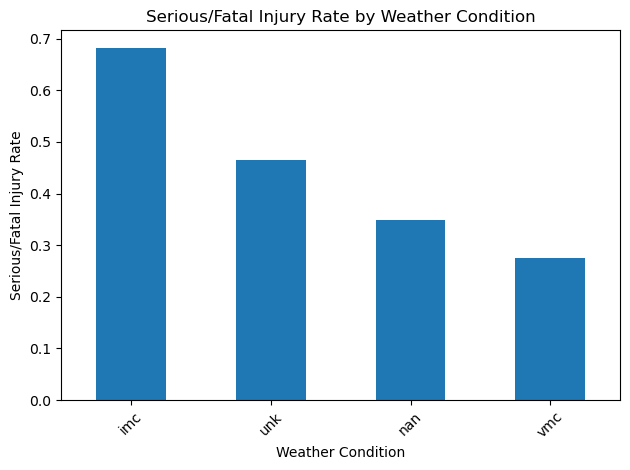

In [ ]:
weather_analysis['serious_fatal_rate'].plot(kind='bar')

plt.title("Serious/Fatal Injury Rate by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Serious/Fatal Injury Rate")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

##### IMC conditions show consistently higher serious/fatal rates, suggesting reduced visibility operations increase accident severity risk.

### 1.2 Phase of Flight and Accident Severity

##### The analysis shows variation in both aircraft destruction rates and serious/fatal injury rates across different phases of flight.

##### Takeoff and landing phases tend to exhibit higher risk compared to cruise phases, indicating that transitional flight stages are more vulnerable to accidents.

In [ ]:
phase_analysis = df1.groupby('broad_phase_of_flight').agg(
    accidents=('event_id', 'count'),
    destruction_rate=('total_destruction', 'mean'),
    serious_fatal_rate=('serious_or_fatal', 'mean')
).sort_values(by='serious_fatal_rate', ascending=False)

phase_analysis.head()

,accidents,destruction_rate,serious_fatal_rate
broad_phase_of_flight,,,
other,2,0.000000,0.500000
unknown,11,0.363636,0.454545
maneuvering,129,0.294574,0.410853
climb,53,0.283019,0.358491
nan,15436,0.106245,0.338235


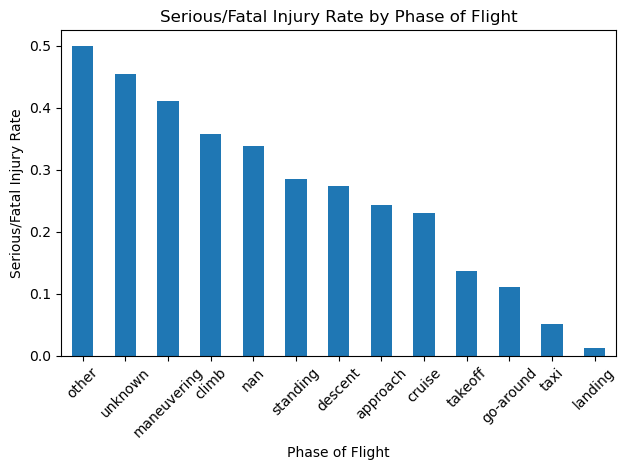

In [ ]:
phase_analysis['serious_fatal_rate'].plot(kind='bar')
plt.title("Serious/Fatal Injury Rate by Phase of Flight")
plt.xlabel("Phase of Flight")
plt.ylabel("Serious/Fatal Injury Rate")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

##### The analysis suggests that maneuvering and climb phases of flight are associated with higher accident severity, both in terms of aircraft destruction and serious or fatal injuries. These phases involve complex aircraft handling and transitional flight conditions, which may increase operational risk.
##### A significant portion of the dataset contains missing values in the 'broad_phase_of_flight' field, which appear as 'nan' after preprocessing. This limits the reliability of aggregated results and suggests that data completeness is a key limitation in the analysis.

#### 1.3 The engine type as it relates to accidents
##### What we will be investigating,
##### -accident frequency per engine type
##### -destruction rate (total_destruction)
##### -injury severity (serious_or_fatal)

In [ ]:
engine_analysis = df1.groupby('engine_type').agg(
    accidents=('event_id', 'count'),
    destruction_rate=('total_destruction', 'mean'),
    serious_fatal_rate=('serious_or_fatal', 'mean')
).sort_values(by='serious_fatal_rate', ascending=False)

engine_analysis.head(10)

,accidents,destruction_rate,serious_fatal_rate
engine_type,,,
nan,3225,0.179535,0.382326
turbo prop,931,0.182599,0.361976
turbo jet,71,0.154930,0.309859
unknown,105,0.276190,0.295238
piston,12836,0.078373,0.292069
turbofan,702,0.049858,0.205128
turbo shaft,9,0.000000,0.111111
geared turbofan,12,0.000000,0.000000
unk,1,0.000000,0.000000


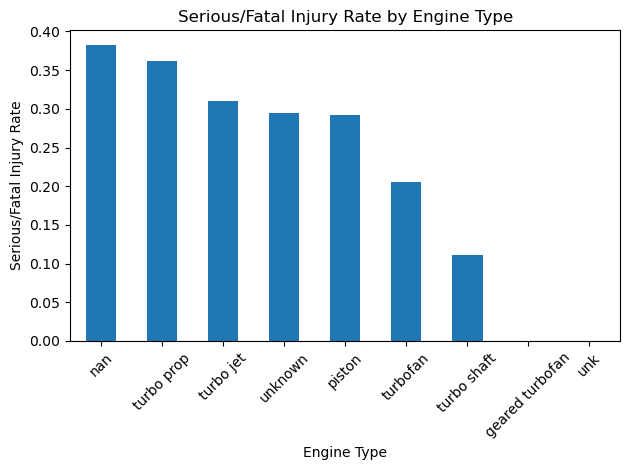

In [ ]:
engine_analysis['serious_fatal_rate'].plot(kind='bar')
plt.title("Serious/Fatal Injury Rate by Engine Type")
plt.xlabel("Engine Type")
plt.ylabel("Serious/Fatal Injury Rate")

plt.xticks(rotation=45)  
plt.tight_layout()       
plt.show()

##### From the plot above, we can see that the turbo prop and turbo jet engine have recorded the highest number of accidents

#### 1.4 Investigating the number of engines the aircraft has and if they have anyting to do with the number of accidents
##### we will be testing
##### -accident frequency per engine count
##### -destruction rate
##### -serious/fatal injury rate

In [ ]:
engine_count_analysis = df1.groupby('number_of_engines').agg(
    accidents=('event_id', 'count'),
    destruction_rate=('total_destruction', 'mean'),
    serious_fatal_rate=('serious_or_fatal', 'mean')
).sort_values(by='serious_fatal_rate', ascending=False)

engine_count_analysis

,accidents,destruction_rate,serious_fatal_rate
number_of_engines,,,
0.0,5,0.200000,0.400000
2.0,2473,0.135463,0.325920
1.0,13230,0.077324,0.294709
3.0,26,0.038462,0.230769
4.0,67,0.089552,0.194030


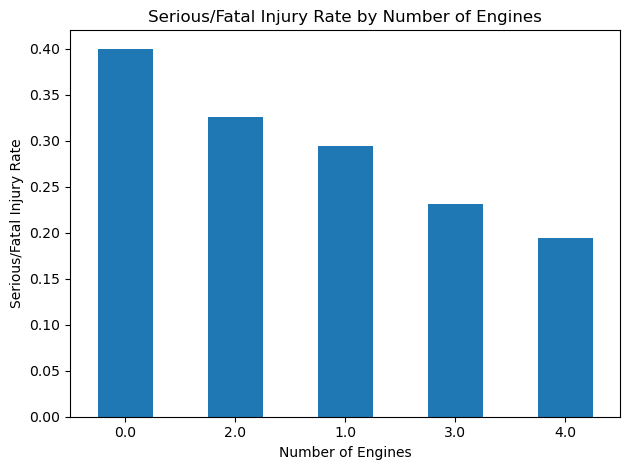

In [ ]:
engine_count_analysis['serious_fatal_rate'].plot(kind='bar')

plt.title("Serious/Fatal Injury Rate by Number of Engines")
plt.xlabel("Number of Engines")
plt.ylabel("Serious/Fatal Injury Rate")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

##### From the plot above, we see that the higher the number of engines a jet has, the lower the number of accidents

#### 1.5 Investigating the purpose of the flight
##### Under this column, we will measure,
##### accident frequency per flight purpose
##### destruction rate
##### serious/fatal injury rate

In [ ]:
purpose_analysis = df1.groupby('purpose_of_flight').agg(
    accidents=('event_id', 'count'),
    destruction_rate=('total_destruction', 'mean'),
    serious_fatal_rate=('serious_or_fatal', 'mean')
).sort_values(by='serious_fatal_rate', ascending=False)

purpose_analysis.head(10)

,accidents,destruction_rate,serious_fatal_rate
purpose_of_flight,,,
asho,2,1.000000,1.000000
air race show,15,0.400000,0.666667
firefighting,12,0.333333,0.583333
unknown,305,0.285246,0.547541
aerial observation,147,0.163265,0.496599
skydiving,157,0.197452,0.484076
glider tow,29,0.068966,0.448276
banner tow,86,0.069767,0.430233
other work use,121,0.099174,0.404959


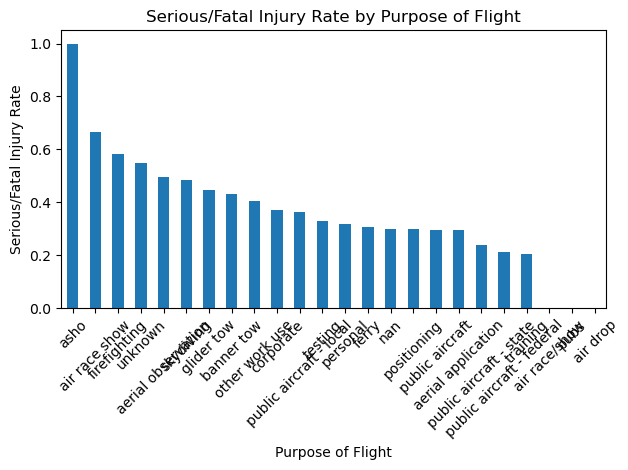

In [ ]:
purpose_analysis['serious_fatal_rate'].plot(kind='bar')

plt.title("Serious/Fatal Injury Rate by Purpose of Flight")
plt.xlabel("Purpose of Flight")
plt.ylabel("Serious/Fatal Injury Rate")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Column Removal
- inspect the dataframe and drop any columns that have too many NaNs

##### We need to identify and clean columns with more than 20,000 non-nulls.

In [ ]:
non_null_counts = df1.notna().sum().sort_values(ascending=False)
non_null_counts

event_id                  17892
engine_type               17892
make_model_pair           17892
make_clean                17892
is_large_aircraft         17892
total_destruction         17892
serious_or_fatal          17892
eastimated_passengers     17892
broad_phase_of_flight     17892
weather_condition         17892
total_uninjured           17892
total_minor_injuries      17892
total_serious_injuries    17892
total_fatal_injuries      17892
purpose_of_flight         17892
investigation_type        17892
aircraft_type_id          17892
model                     17892
accident_number           17892
make                      17892
event_date                17892
aircraft_category         17892
aircraft_damage           17892
amateur_built             17892
country                   17891
location                  17888
registration_number       17728
far_description           17548
injury_severity           17173
publication_date          17104
latitude                  15990
longitud

In [ ]:
df1.shape

(17892, 38)

##### From the output, we can see we have less rows than the threshold given. This is because, i matched the name of aircrafts in the
##### make column that had naming issues and cleaned the dataset

In [ ]:
df1.shape

(17892, 38)

In [ ]:
df1.isna().sum().sort_values(ascending=False).head(10)

schedule             15750
air_carrier           9437
airport_code          6238
airport_name          6130
report_status         3793
number_of_engines     2091
longitude             1905
latitude              1902
publication_date       788
injury_severity        719
dtype: int64

In [ ]:
df1.columns

Index(['event_id', 'investigation_type', 'accident_number', 'event_date',
       'location', 'country', 'latitude', 'longitude', 'airport_code',
       'airport_name', 'injury_severity', 'aircraft_damage',
       'aircraft_category', 'registration_number', 'make', 'model',
       'amateur_built', 'number_of_engines', 'engine_type', 'far_description',
       'schedule', 'purpose_of_flight', 'air_carrier', 'total_fatal_injuries',
       'total_serious_injuries', 'total_minor_injuries', 'total_uninjured',
       'weather_condition', 'broad_phase_of_flight', 'report_status',
       'publication_date', 'eastimated_passengers', 'serious_or_fatal',
       'total_destruction', 'is_large_aircraft', 'make_clean',
       'make_model_pair', 'aircraft_type_id'],
      dtype='object')

### Save DataFrame to csv
- its generally useful to save data to file/server after its in a sufficiently cleaned or intermediate state
- the data can then be loaded directly in another notebook for further analysis
- this helps keep your notebooks and workflow readable, clean and modularized

In [ ]:
df1.to_csv("aviation_cleaned_data.csv", index=False)